<a href="https://colab.research.google.com/github/Nermeen-Moussa/ML-DL-Reference-Guide/blob/machine-learning/LogisticRegression_MachineLearning_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**a supervised machine learning and classification method. It predicts the probability that a data input belongs to a specific category. It handles binary outcomes like yes or no, true or false, or 0 and 1**

**y=1/(e^-(mx+b))**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score


In [2]:
d = {'miles_per_week': [37,39,46,51,88,17,18,20,21,22,23,24,25,27,28,29,30,31,32,33,34,38,40,42,57,68,35,36,41,43,45,47,49,50,52,53,54,55,56,58,59,60,61,63,64,65,66,69,70,72,73,75,76,77,78,80,81,82,83,84,85,86,87,89,91,92,93,95,96,97,98,99,100,101,102,103,104,105,106,107,109,110,111,113,114,115,116,116,118,119,120,121,123,124,126,62,67,74,79,90,112],
      'completed_50m_ultra': ['no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','no','yes','yes','yes','yes','no','yes','yes','yes','no','yes','yes','yes','yes','yes','yes','yes','yes','no','yes','yes','yes','yes','yes','yes','yes','no','yes','yes','yes','yes','yes','yes','yes','no','yes','yes','yes','yes','yes','yes','yes','no','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes','yes',]}

In [4]:
df=pd.DataFrame(data=d)
df.head()

,miles_per_week,completed_50m_ultra
0,37,no
1,39,no
2,46,no
3,51,no
4,88,no


In [5]:
finished_race=['no','yes']
enc=OrdinalEncoder(categories=[finished_race])
df['completed_50m_ultra']=enc.fit_transform(df[['completed_50m_ultra']])
df.head()

,miles_per_week,completed_50m_ultra
0,37,0.0
1,39,0.0
2,46,0.0
3,51,0.0
4,88,0.0


<Axes: xlabel='completed_50m_ultra', ylabel='count'>

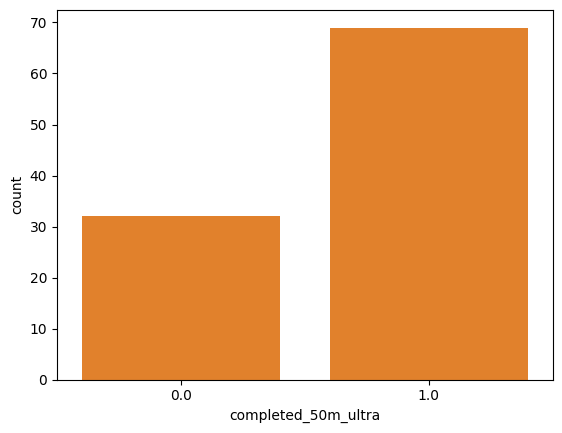

In [8]:
plt.scatter(df.miles_per_week,df.completed_50m_ultra)
sns.countplot(x='completed_50m_ultra',data=df)


In [10]:
X=df.iloc[:,0:1]
y=df.iloc[:,1]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
X_train,X_test,y_train,y_test.shape

(    miles_per_week
 89             119
 26              35
 42              61
 70              98
 15              29
 ..             ...
 60              85
 71              99
 14              28
 92             123
 51              75
 
 [80 rows x 1 columns],
     miles_per_week
 84             114
 55              80
 66              93
 67              95
 45              65
 39              58
 22              40
 44              64
 10              23
 0               37
 18              32
 30              45
 97              74
 33              50
 77             105
 4               88
 93             124
 78             106
 12              25
 31              47
 76             104,
 89    1.0
 26    1.0
 42    1.0
 70    1.0
 15    0.0
      ... 
 60    1.0
 71    1.0
 14    0.0
 92    1.0
 51    0.0
 Name: completed_50m_ultra, Length: 80, dtype: float64,
 (21,))

In [11]:
model=LogisticRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
model.score(X_test,y_test)

0.8571428571428571

In [12]:
print("Confusion Matrix")
print(confusion_matrix(y_test,y_pred))
print("Classification Report")
print(classification_report(y_test,y_pred))

Confusion Matrix
[[ 6  2]
 [ 1 12]]
Classification Report
              precision    recall  f1-score   support

         0.0       0.86      0.75      0.80         8
         1.0       0.86      0.92      0.89        13

    accuracy                           0.86        21
   macro avg       0.86      0.84      0.84        21
weighted avg       0.86      0.86      0.86        21

